fmt: off

In [929]:
import pandas as pd
import torch 
import botorch
import matplotlib 
import matplotlib.pyplot as plt 
import numpy as np

#ok 

In [930]:
%matplotlib inline
#plt.rcParams['figure.figsize'] = [10, 8]
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11


#ok

In [931]:
# moving into the repo

import os

#for macmini
#repo_dir = "/Users/ayyan/Library/CloudStorage/OneDrive-UniversityofIllinois-Urbana/Meta/SustainableConcrete"
#filename = "/Users/ayyan/Library/CloudStorage/OneDrive-UniversityofIllinois-Urbana/Meta/SustainableConcrete/data/Training.csv"

#for macbook
repo_dir = "/Users/ayyaniqbal/Library/CloudStorage/OneDrive-UniversityofIllinois-Urbana/Meta/SustainableConcrete"
filename = "/Users/ayyaniqbal/Library/CloudStorage/OneDrive-UniversityofIllinois-Urbana/Meta/SustainableConcrete/data/Training.csv"

# if not os.getcwd()[-len(repo_name) :] == repo_name:
os.chdir(repo_dir)
os.getcwd()

#ok

'/Users/ayyaniqbal/Library/CloudStorage/OneDrive-UniversityofIllinois-Urbana/Meta/SustainableConcrete'

In [932]:
#from utils import load_concrete_strength

#load_concrete_strength(filename)

#ok

In [933]:
import sys

if repo_dir not in sys.path:
    sys.path.append("/home/jkusuma/concrete/SustainableConcrete")
    sys.path.append("/data/users/sebastianament/github/SustainableConcrete")

import importlib

import models
import utils

#ok

In [934]:
importlib.reload(utils)
from utils import load_concrete_strength

verbose = True
# verbose = False

#ok

Load data and partition into the right X and Y frames

In [935]:
# define which columns of the data we are using as inputs to the model
X_columns = [
    "Cement (kg/m3)",
    "Fly Ash (kg/m3)",
    "Slag (kg/m3)",
    "Water (kg/m3)",
    "HRWR (kg/m3)",
    "Fine Aggregate (kg/m3)",
    "Coarse Aggregates (kg/m3)",
    "Clay0 (kg/m3)",
    "Clay1 (kg/m3)",
    "Clay2 (kg/m3)",
    "Material Source",
    "Temp (C)",
    "Time",
]

#ok

In [936]:
# first define the bounds of the search space
_TOTAL_BINDER_NAMES = [
    "Cement (kg/m3)",
    "Fly Ash (kg/m3)",
    "Slag (kg/m3)",
    "Clay0 (kg/m3)",
    "Clay1 (kg/m3)",
    "Clay2 (kg/m3)",
]

bounds_dict = {
    # NOTE: the pure cement baseline is outside of these bounds (~752), as is Dec_2022_2 (~211)
    # "Cement": (300, 700),
    # "Fly Ash": (0, 350),
    # "Slag": (0, 450),
    # "Coarse Aggregate": (800, 1950),
    # "Fine Aggregate": (600, 1700),
    # "Time": (0, 28),  # up to 28 days
    # "Cement (kg/m3)": (200, 900),
    "Cement (kg/m3)": (0, 1000),
    "Fly Ash (kg/m3)": (0, 700),
    "Slag (kg/m3)": (0, 1200),
    "Clay0 (kg/m3)": (0, 150),
    "Clay1 (kg/m3)": (0, 150),
    "Clay2 (kg/m3)": (0, 150),
    "Water (kg/m3)": (0, 600),
    "HRWR (kg/m3)": (0.0, 20.0),
    "MRWR (kg/m3)": (0.0, 20),
    "VMA (oz/cwt)": (0.0, 10),  # TODO: determine this
    "AE (oz/cwt)": (0.0, 10),  # TODO: determine this
    "Fine Aggregate (kg/m3)": (400, 2400),
    "Coarse Aggregates (kg/m3)": (0, 2000),
    "Material Source": (0, 2),
    # "w/b": (0.2, 0.5),
    "Temp (C)": (4.5, 22),
    "Time": (0, 28),  # up to 28 days
}

min_binder, max_binder = 0, 0
for name in _TOTAL_BINDER_NAMES:
    min_binder += bounds_dict[name][0]
    max_binder += bounds_dict[name][1]

bounds_dict.update( # fix relative to binder ratios
    {
        "Water (kg/m3)": (0.2 * min_binder, 0.5 * max_binder),
        "HRWR (kg/m3)": (0, 0.1 * max_binder),  # linear constraint also applies, see below
        "MRWR (kg/m3)": (0, 0.1 * max_binder),  # linear constraint also applies, see below
    }
 )

bounds = torch.tensor([bounds_dict[col] for col in X_columns]).T
if verbose:
    print("The lower and upper bounds for the respective variables are set to:")
    for col, bound in zip(X_columns, bounds.T):
        print(f"\t- {col}: [{bound[0].item()}, {bound[1].item()}]")
    print()

The lower and upper bounds for the respective variables are set to:
	- Cement (kg/m3): [0.0, 1000.0]
	- Fly Ash (kg/m3): [0.0, 700.0]
	- Slag (kg/m3): [0.0, 1200.0]
	- Water (kg/m3): [0.0, 1675.0]
	- HRWR (kg/m3): [0.0, 335.0]
	- Fine Aggregate (kg/m3): [400.0, 2400.0]
	- Coarse Aggregates (kg/m3): [0.0, 2000.0]
	- Clay0 (kg/m3): [0.0, 150.0]
	- Clay1 (kg/m3): [0.0, 150.0]
	- Clay2 (kg/m3): [0.0, 150.0]
	- Material Source: [0.0, 2.0]
	- Temp (C): [4.5, 22.0]
	- Time: [0.0, 28.0]



In [937]:
data = load_concrete_strength(
    filename,
    mix_name_column="Mix Name",
    verbose=verbose,
    X_columns=X_columns,
    process_batch_names_from_mix_name=False,
    bounds_dict=bounds_dict,
)

The data has 474 rows and 32 columns, which are:
	- Mix Name
	- Description
	- Mortar or Concrete
	- Material Source
	- Binder (kg/m3)
	- Cement (kg/m3)
	- Fly Ash (kg/m3)
	- Slag (kg/m3)
	- Clay0 (kg/m3)
	- Clay1 (kg/m3)
	- Clay2 (kg/m3)
	- w/b
	- Water (kg/m3)
	- MRWR (kg/m3)
	- HRWR (kg/m3)
	- HRWR (oz/cwt binder)
	- VMA (oz/cwt)
	- AE (oz/cwt)
	- Fine Aggregate (kg/m3)
	- Coarse Aggregates (kg/m3)
	- Temp (C)
	- Time
	- GWP
	- Strength1 (psi)
	- Strength2 (psi)
	- Strength3 (psi)
	- Strength (Mean)
	- Strength (Std)
	- # of measurements
	- Cement replacement (ratio)
	- Slump (in)
	- Cost Factor

Found no batch names.
Separating model inputs and outputs:
Input columns: 
	- Cement (kg/m3)
	- Fly Ash (kg/m3)
	- Slag (kg/m3)
	- Water (kg/m3)
	- HRWR (kg/m3)
	- Fine Aggregate (kg/m3)
	- Coarse Aggregates (kg/m3)
	- Clay0 (kg/m3)
	- Clay1 (kg/m3)
	- Clay2 (kg/m3)
	- Material Source
	- Temp (C)
	- Time
Output (Mean) columns
	- GWP
	- Strength (Mean)
Output (Std) columns
	- Strength (Std)


In [938]:
# distribution of w/b ratios
# plt.hist(df["Water (kg/m3)"] / (
#     df["Cement (kg/m3)"] + df["Fly Ash (kg/m3)"] + df["Slag (kg/m3)"]
# ))

Implement learning algorithm based on partitioned X and Y frames

In [939]:
# data is a SustainableConcreteDataset object
# NOTE: Could add 3-day strength
model_strength_days = [
    1,
    28,
]  # the strength days that are converted to optimization objectives
model = models.SustainableConcreteModel(strength_days=model_strength_days)
model.fit_gwp_model(data)
model.fit_strength_model(data, use_fixed_noise=False)

SingleTaskGP(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (raw_noise_constraint): Interval(1.000E-06, 1.000E+00)
    )
  )
  (mean_module): ConstantMean()
  (covar_module): AdditiveKernel(
    (kernels): ModuleList(
      (0): ScaleKernel(
        (base_kernel): MaternKernel(
          (raw_lengthscale_constraint): Interval(1.000E-02, 1.000E+03)
        )
        (raw_outputscale_constraint): Interval(1.000E-02, 1.000E+02)
      )
      (1): ScaleKernel(
        (base_kernel): RBFKernel(
          (raw_lengthscale_constraint): Interval(1.000E-02, 1.000E+03)
        )
        (raw_outputscale_constraint): Interval(1.000E-02, 1.000E+02)
      )
    )
  )
  (outcome_transform): Standardize()
  (input_transform): ChainedInputTransform(
    (tf1): AffineInputTransform()
    (tf2): Log10()
    (tf3): Normalize()
  )
)

In [940]:
model.strength_model.likelihood.noise

tensor([0.0257], dtype=torch.float64, grad_fn=<AddBackward0>)

In [941]:
model_list = model.get_model_list()

In [942]:
# NOTE: the original search space bounds are not satisfied by some of the data.
X, Y, Yvar, X_bounds = data.gwp_data
ind = range(len(X))
post_list = model_list.posterior(X)

[torch.Size([111, 1]), torch.Size([111])]

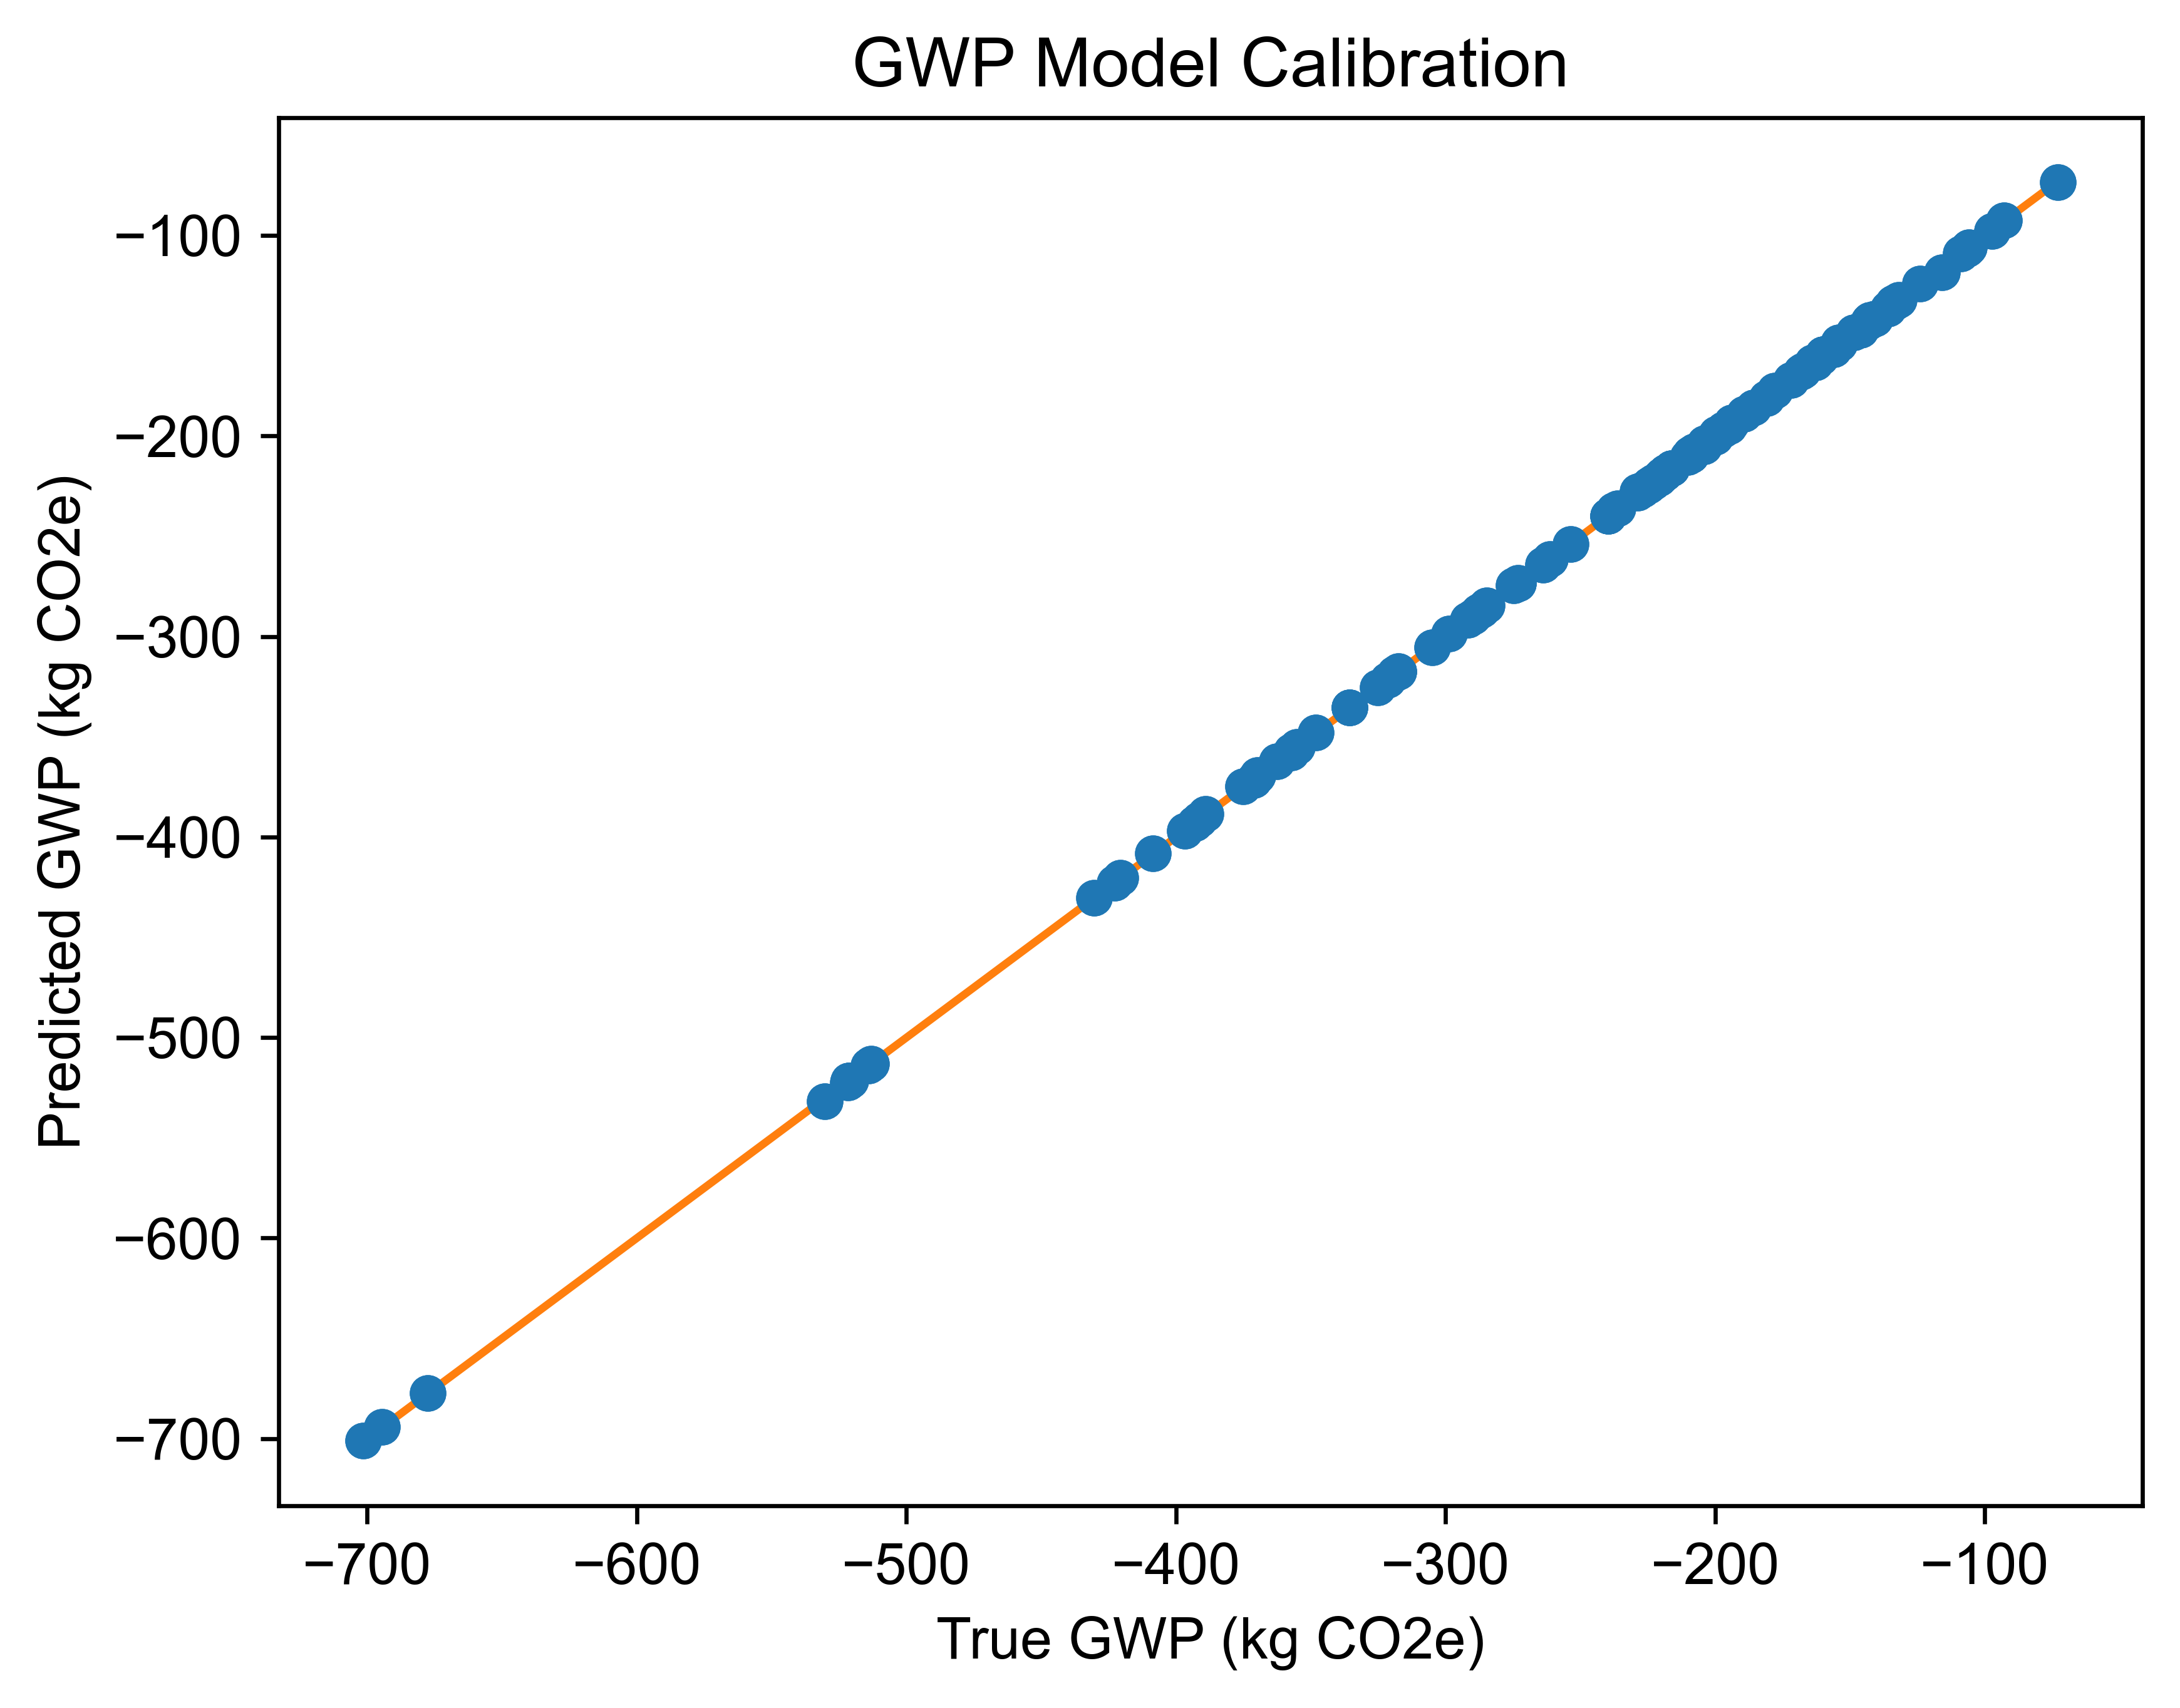

In [943]:
# CHECK_gwp = 1

# if CHECK_gwp:
obj_id = 0  # 0 is GWP, 1 is 1 day, 2, is 28-day strength
# Y[ind], post_list.mean[:, 0], Yvar[ind], post_list.variance[:, obj_id] # variance for GWP looking good, since it gets rounded to ~ 1%.
truth = Y[ind]
pred = post_list.mean[:, obj_id].detach()
# truth_std = Yvar[ind][ind].sqrt().detach()
pred_std = post_list.variance[:, obj_id].sqrt().detach()
plt.figure(dpi=600)
plt.title("GWP Model Calibration")
plt.ylabel("Predicted GWP (kg CO2e)")
plt.xlabel("True GWP (kg CO2e)")
plt.scatter(truth, pred)
plt.errorbar(truth, pred, yerr=2 * pred_std, fmt="o")
line = torch.arange(truth.min(), truth.max())
plt.plot(line, line)

[truth.shape, pred.shape]


In [944]:
X, Y, Yvar = data.strength_data_by_time(1)
ind = range(len(X))
post_list = model_list.posterior(X[..., :-1])
Y.shape

torch.Size([109, 1])

[torch.Size([109, 1]), torch.Size([109])]

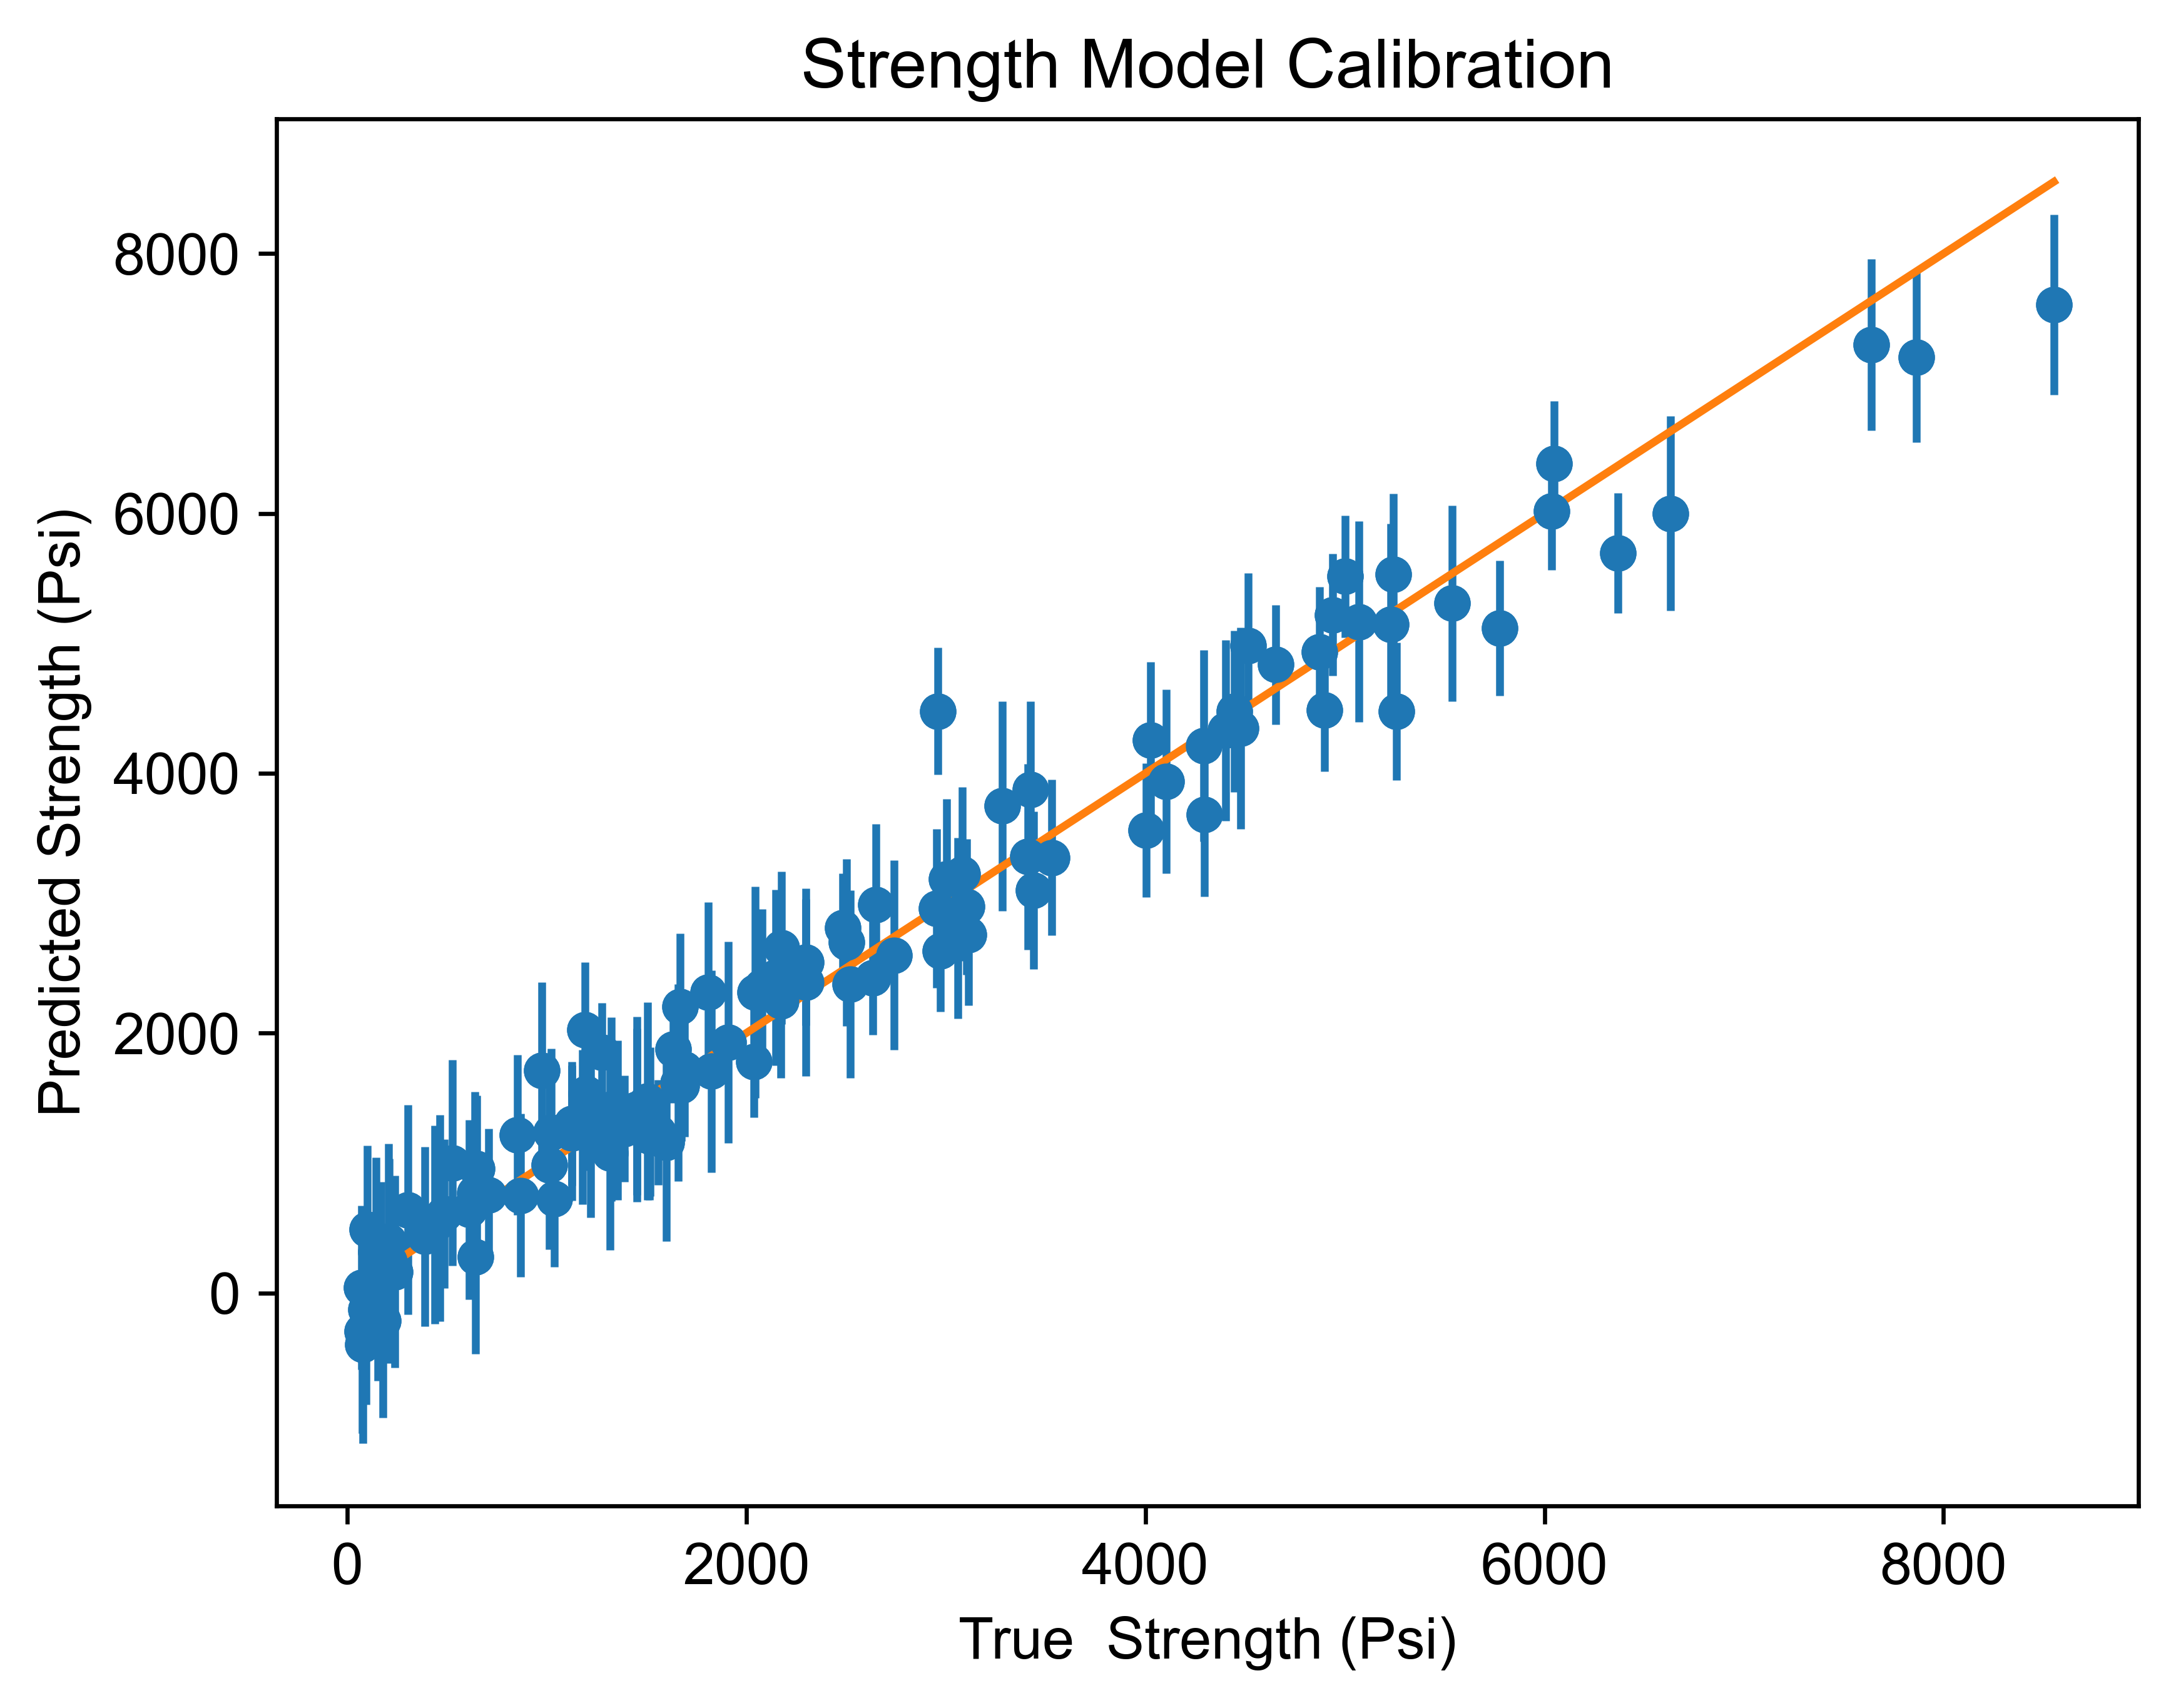

In [945]:
# CHECK_gwp = 1

# if CHECK_gwp:
obj_id = 1  # 0 is GWP, 1 is 1 day, 2, is 28-day strength
# Y[ind], post_list.mean[:, 0], Yvar[ind], post_list.variance[:, obj_id] # variance for GWP looking good, since it gets rounded to ~ 1%.
truth = Y[ind]
pred = post_list.mean[:, obj_id].detach()
# truth_std = Yvar[ind][ind].sqrt().detach()
pred_std = post_list.variance[:, obj_id].sqrt().detach()
plt.figure(dpi=600)
plt.title("Strength Model Calibration")
plt.ylabel("Predicted Strength (Psi)")
plt.xlabel("True  Strength (Psi)")
plt.scatter(truth, pred)
plt.errorbar(truth, pred, yerr=2 * pred_std, fmt="o")
line = torch.arange(truth.min(), truth.max())
plt.plot(line, line)

[truth.shape, pred.shape]

In [946]:
# CHECK_1day = 1

# if CHECK_1day:
time = 14
Xt, truth, truth_var = data.strength_data_by_time(time)
truth_std = truth_var.sqrt()
obj_id_post = 2  # 0 is GWP, 1 is 1 day, 2, is 28-day strength
# truth = data.Y[row_ind, obj_id][ind]
pred = post_list.mean[:, obj_id_post].detach()

# truth_std = data.Yvar[row_ind, obj_id][ind].sqrt()
pred_std = post_list.variance[:, obj_id_post].sqrt().detach()

#fig = plt.figure(dpi=200)
#plt.title(f"Day-{time} Strength Calibration")
#plt.ylabel("Prediction")
#plt.xlabel("Truth")
#plt.scatter(truth[1:18], pred)
#lw = 3
#plt.errorbar(truth, pred, yerr=2 * pred_std, fmt="o", linewidth=lw)
#plt.errorbar(truth.squeeze(), pred, xerr=2 * truth_std.squeeze(), fmt="o", linewidth=lw/2)
#line = torch.arange(truth.min(), truth.max())
#plt.plot(line, line, color="black", linestyle=":")
#plt.show()

[truth.shape, pred.shape]  # truth value has more rows than predictions

[torch.Size([42, 1]), torch.Size([109])]

GWP and Curve prediction

In [947]:
X_columns

['Cement (kg/m3)',
 'Fly Ash (kg/m3)',
 'Slag (kg/m3)',
 'Water (kg/m3)',
 'HRWR (kg/m3)',
 'Fine Aggregate (kg/m3)',
 'Coarse Aggregates (kg/m3)',
 'Clay0 (kg/m3)',
 'Clay1 (kg/m3)',
 'Clay2 (kg/m3)',
 'Material Source',
 'Temp (C)',
 'Time']

In [948]:
# Not needed here



#X_plot_dict = {
#    "Cement (kg/m3)": 500.65,
#    "Fly Ash (kg/m3)": 172.58,
#    "Slag (kg/m3)": 100.44,
#   "Clay0 (kg/m3)": 0,
#    "Clay1 (kg/m3)": 0,
#    "Clay2 (kg/m3)": 0,
#    "Water (kg/m3)": 233.33,
#    "HRWR (kg/m3)": 0.891,
#    "MRWR (kg/m3)": 0,
#    "Fine Aggregate (kg/m3)": 611.11,
#    "Coarse Aggregates (kg/m3)": 1175.58,
#    "Material Source": 0,
#    "Temp (C)": 22
#}

#X_plot = torch.tensor([[X_plot_dict[col] for col in X_columns[:-1]]])

# Correctly print mixture details
#print("\n=== Concrete Mix Composition ===")
#for col, val in zip(X_columns[:-1], X_plot[0]):
#    print(f"{col:<30}: {val.item():.2f}")

#total_binder = sum(X_plot_dict[name] for name in _TOTAL_BINDER_NAMES if name in X_columns)
#water = X_plot_dict["Water (kg/m3)"]
#w_b_ratio = water / total_binder if total_binder else 0

#print(f"\nTotal Binder (kg/m3): {total_binder:.2f}")
#print(f"Water-to-Binder Ratio (w/b): {w_b_ratio:.3f}\n")

In [949]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.ticker import MultipleLocator



## Run GWP prediction
def plot_strength_curve(
    model,
    Xs_plot,
    plot_uncertainties: bool = True,
    observed_data=None,
    observed_times=None,
    color_1="green",
    color_2="blue",
    label_1="Predictions",
    label_2="Observations",
    title="Predicted Mix",
    xlim=(0.15, 30),
    ylim=(0, 16000),
    figsize=(2, 2),
    dpi=600,
    create_fig: bool = True,
):
    # GWP prediction
    gwp_pred = model.gwp_model.posterior(Xs_plot).mean

    ## Run strength curve prediction
    # define time sampling intervals
    t_start, t_stop = 0.2, 35.0
    num_t = 1024  # default value is 1024
    plot_times = torch.arange(t_start, t_stop, step=(t_stop - t_start) / num_t)

    # plot_times = torch.tensor([0.2, 0.3, 0.5, 0.8, 1.0, 2.0, 3.0, 5.0, 28.0])
    # num_t = plot_times.size(dim=0)
    tableau = list(mcolors.TABLEAU_COLORS.values())

    if create_fig:
        plt.figure(dpi=dpi, figsize=figsize)


    for i in range(Xs_plot.shape[0]):
        X_plot = Xs_plot[[i]]

        # adding time dimension to composition inputs
        X_w_time = torch.cat(
            (X_plot.expand(num_t, X_plot.shape[-1]), plot_times.unsqueeze(-1)), dim=-1
        )

        # call strength curve prediction
        curve_post = model.strength_model.posterior(X_w_time)
        curve_mean = curve_post.mean.detach().squeeze()
        curve_std = curve_post.variance.sqrt().detach().squeeze()

        ## Generate plot
        #color_1 = "green"
        color_1 = tableau[i]

        #plt.title(f"{title} with GWP = {', '.join([str(round(val.item(), 2)) for val in gwp_pred])}")
        #plt.title(f"{title} , GWP = {', '.join([str(round(val.item(), 2)) for val in gwp_pred])}")
        #plt.title(f"{title} , GWP = {', '.join([str(round(abs(val.item()), 2)) for val in gwp_pred])}")



        plt.plot(plot_times, curve_mean, color=color_1)
        #plt.ylabel(r"$\mathbf{f'}_\mathbf{c}$ (ksi)", fontweight='bold')
        #plt.xlabel("Time (Days)", fontweight='bold')
        nsigma = 2
        # plot uncertainties or not
        if plot_uncertainties:
            plt.fill_between(
                plot_times,
                curve_mean - nsigma * curve_std,
                curve_mean + nsigma * curve_std,
                alpha=0.2,
                #label=f"Predicted {i}",
                label=f"Predicted",
                color=color_1,
            )

        # if the mix is in the dataset, could grab the observed strength data ("observed_data") from Y
        if observed_data is not None:
            plt.plot(
                observed_times, observed_data, "o", label="Observations", c=color_1
            )
            plt.legend()

        plt.xscale("log")
        special_times = [1, 3, 5, 14, 28]
        special_labels = [
            "1",
            "3",
            "5",
            "14",
            "28",
        ]
        plt.xticks(special_times, special_labels)
        #plt.grid(visible=True)

        xlim = (0.25, 35)
        ylim = (-500, 16000)
        plt.xlim(xlim)
        plt.ylim(ylim)

        ax = plt.gca()

    ax.yaxis.set_major_locator(MultipleLocator(4000))
    ax.yaxis.set_minor_locator(MultipleLocator(2000))
    
    # Set spine (axis border) thickness
    for spine in ax.spines.values():
        spine.set_linewidth(1)

    # Set major tick thickness
    ax.tick_params(which='major', width=1, length=8)  # width = line thickness, length = tick size

    # Set minor tick thickness
    ax.tick_params(which='minor', width=1, length=4)
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)

    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{int(y/1000)}'))

In [950]:
X = data.gwp_data[0] #here, it is taking the inputs from excel file
X_M129 = X[[-11]] #here -11 meaans 11th mix from the bottom
dict(zip(X_columns, X_M129.T))

{'Cement (kg/m3)': tensor([179.], dtype=torch.float64),
 'Fly Ash (kg/m3)': tensor([0.], dtype=torch.float64),
 'Slag (kg/m3)': tensor([191.], dtype=torch.float64),
 'Water (kg/m3)': tensor([185.], dtype=torch.float64),
 'HRWR (kg/m3)': tensor([0.], dtype=torch.float64),
 'Fine Aggregate (kg/m3)': tensor([800.], dtype=torch.float64),
 'Coarse Aggregates (kg/m3)': tensor([1051.], dtype=torch.float64),
 'Clay0 (kg/m3)': tensor([0.], dtype=torch.float64),
 'Clay1 (kg/m3)': tensor([0.], dtype=torch.float64),
 'Clay2 (kg/m3)': tensor([0.], dtype=torch.float64),
 'Material Source': tensor([1.], dtype=torch.float64),
 'Temp (C)': tensor([22.], dtype=torch.float64)}

In [951]:
X_plot = X_M129 
X_plot.shape

torch.Size([1, 12])

In [952]:
X_plot[:, 4]

tensor([0.], dtype=torch.float64)

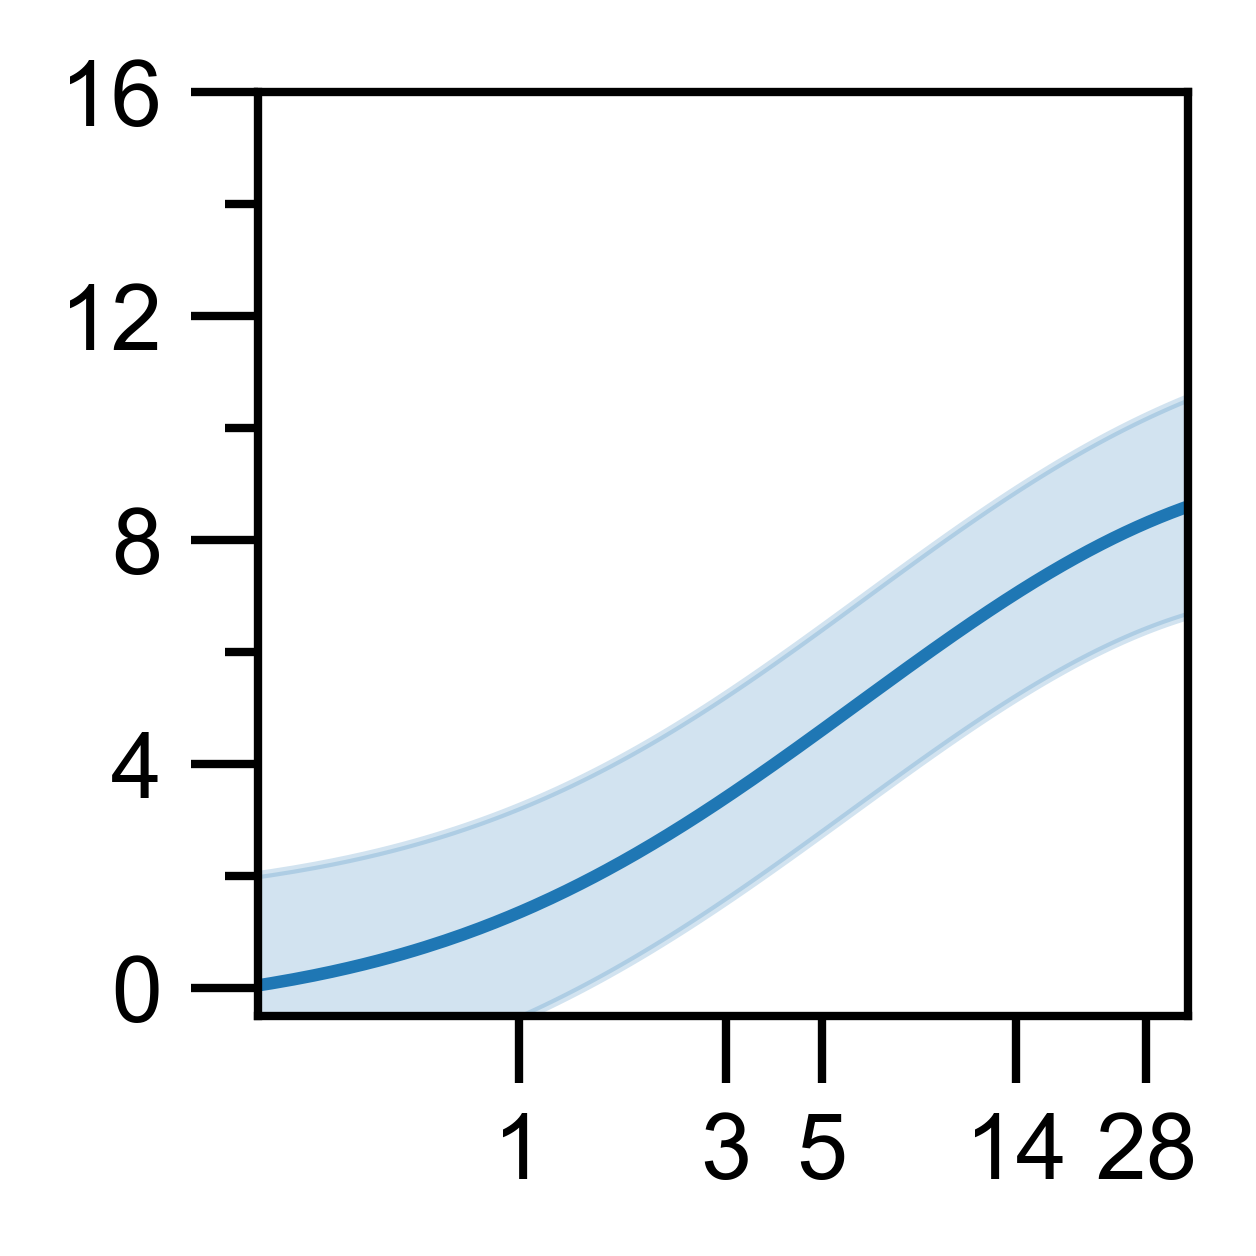

In [953]:
X_plot_2 = X_M129.clone()
#we can add the inputs here

X_plot_2[:, 0] = 300 #cement (kg/m3)
X_plot_2[:, 1] = 300 #fly ash (kg/m3)
X_plot_2[:, 2] = 00 #slag (kg/m3)
X_plot_2[:, 3] = 267 #water (kg/m3)
X_plot_2[:, 4] = 0.5 #HRWR (kg/m3)
X_plot_2[:, 5] = 895 #fine aggregate (kg/m3)
X_plot_2[:, 6] = 1166 #coarse aggregates (kg/m3)
X_plot_2[:, 7] = 0 #clay0 (kg/m3)
X_plot_2[:, 8] = 0 #clay1 (kg/m3)
X_plot_2[:, 9] = 0 #clay2 (kg/m3)
X_plot_2[:, 10] = 0 #material source
X_plot_2[:, 11] = 22 #temp (C)

plot_strength_curve(
    model,
    X_plot_2,
    #title="M139",
    dpi=600,
    create_fig=True,
)
# Add a legend without a border
#plt.legend(loc='upper right', fontsize=8, frameon=True, facecolor='white', edgecolor='white', framealpha=1)

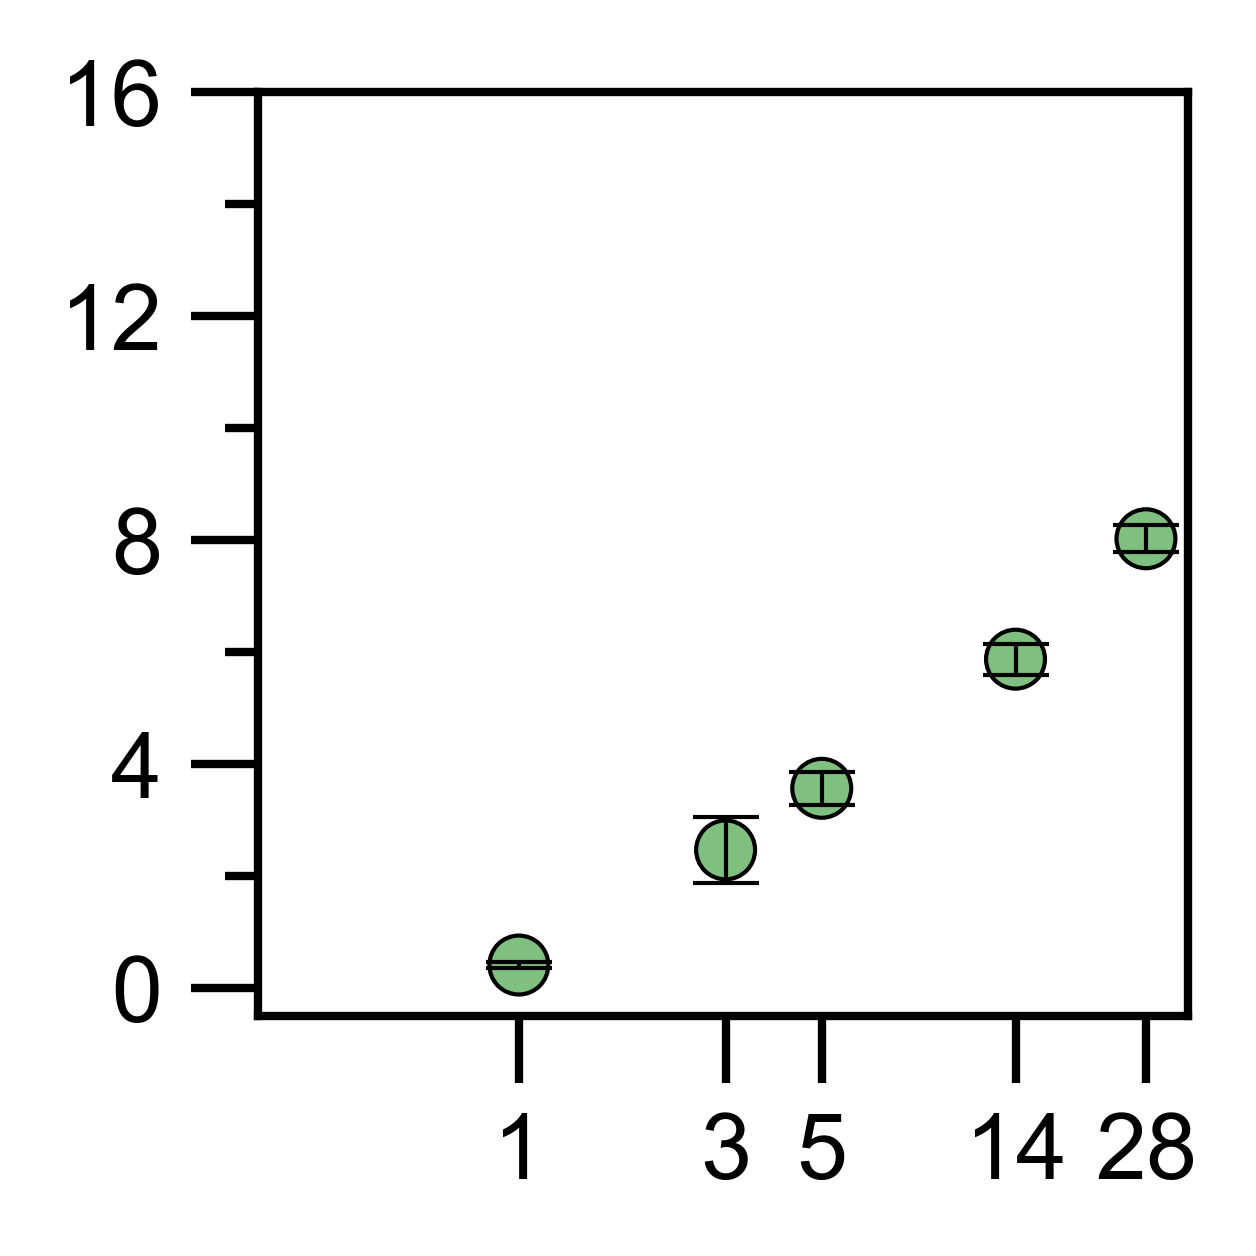

In [954]:
import numpy as np
import matplotlib.pyplot as plt

def plot_scatter_with_errorbars(x_data, y_data, y_std, title=" "):
    plt.figure(dpi=600, figsize=(2, 2), facecolor='none')  # Transparent background

    face_color = (0, 0.5, 0, 0.5)  # RGBA for semi-transparent green
    plt.scatter(
        x_data, y_data,
        facecolors=[face_color] * len(x_data),  # transparent fill
        edgecolors='black',                     # solid border
        s=50, linewidths=0.5
    )


    # Error bars (lines only, fully opaque)
    plt.errorbar(
        x_data, y_data, yerr=y_std, fmt='none', ecolor="black",
        capsize=4, capthick=0.5, elinewidth=0.5, alpha=1
    )

    # Formatting
    #plt.title(title)
    #plt.ylabel(r"$\mathbf{f'}_\mathbf{c}$ (ksi)", fontweight='bold')
    #plt.xlabel("Time (Days)", fontweight='bold')
    plt.xscale("log")  # Log scale for time

    # Custom X-axis tick labels
    special_times = [1, 3, 5, 14, 28]
    special_labels = ["1", "3", "5", "14", "28"]
    plt.xticks(special_times, special_labels)

    #plt.grid(True)
    plt.xlim(0.25, 35)
    plt.ylim(-500, 16000)

    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(1)

    ax.tick_params(which='major', width=1, length=8)
    ax.tick_params(which='minor', width=1, length=4)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{int(y/1000)}'))
    ax.minorticks_on()
    ax.yaxis.set_major_locator(MultipleLocator(4000))
    ax.yaxis.set_minor_locator(MultipleLocator(2000))
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)

    # Transparency settings
    ax.patch.set_alpha(0)

    
    #plt.legend(loc='upper right', fontsize=8, frameon=True, facecolor='white', edgecolor='white', framealpha=1)
    plt.savefig("scm.png", dpi=600, transparent=True)
    plt.show()

# Example usage:
x_values = [1, 3, 5, 14, 28]  
y_values = [413,	2469,	3569,	5875,	8025]  
y_std = [52,	589,	290,	276,	241]  # Standard deviation values




plot_scatter_with_errorbars(x_values, y_values, y_std)


In [955]:
#For training dataset

import os
import pandas as pd

# === Settings ===
output_dir = "training_set_predictions_all"
os.makedirs(output_dir, exist_ok=True)

# Days to predict
prediction_days = torch.tensor([1.0, 3.0, 5.0, 14.0, 28.0])
day_labels = [f"Strength_Day_{int(day.item())}" for day in prediction_days]
uncertainty_labels = [f"Uncertainty_Day_{int(day.item())}" for day in prediction_days]

Xs_plot = data.gwp_data[0]
gwp_preds = model.gwp_model.posterior(Xs_plot).mean.detach().squeeze().numpy()

# Storage for all predictions
records = []

# Loop through all mixes
for i in range(Xs_plot.shape[0]):
    X_plot = Xs_plot[[i]]
    mix_id = f"MIX_{i:03d}"

    # Append time values for strength prediction
    X_with_time = torch.cat(
        (X_plot.expand(prediction_days.shape[0], -1), prediction_days.unsqueeze(-1)),
        dim=1
    )

    # Predict strength
    post = model.strength_model.posterior(X_with_time)
    pred_mean = post.mean.squeeze().detach().numpy()
    pred_std = post.variance.sqrt().squeeze().detach().numpy()

    # Construct row
    row = {
        "Mix_ID": mix_id,
        "GWP": gwp_preds[i]
    }
    row.update(dict(zip(day_labels, pred_mean)))
    row.update(dict(zip(uncertainty_labels, 2 * pred_std)))  # 95% CI

    records.append(row)

    # Optional: save strength curve plot
    plot_strength_curve(
        model,
        X_plot,
        title=mix_id,
        dpi=600,
        create_fig=True,
    )

    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(1)

    ax.tick_params(which='major', width=1, length=8)
    ax.tick_params(which='minor', width=1, length=4)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{int(y/1000)}'))
    ax.minorticks_on()
    ax.yaxis.set_major_locator(MultipleLocator(4000))
    ax.yaxis.set_minor_locator(MultipleLocator(2000))
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)

    plt.savefig(os.path.join(output_dir, f"{mix_id}_curve.png"), dpi=600, bbox_inches='tight')
    plt.close()

# Save all predictions to one CSV
df_all = pd.DataFrame(records)
csv_path = os.path.join(output_dir, "training_strength_predictions.csv")
df_all.to_csv(csv_path, index=False)

print(f"Saved combined CSV and plots for {Xs_plot.shape[0]} mixes to: {csv_path}")


Saved combined CSV and plots for 111 mixes to: training_set_predictions_all/training_strength_predictions.csv


In [956]:
#For testing dataset

import os
import pandas as pd
import torch
import matplotlib.pyplot as plt

# === 1. Define input columns expected by the model ===
X_columns = [
    "Cement (kg/m3)",
    "Fly Ash (kg/m3)",
    "Slag (kg/m3)",
    "Water (kg/m3)",
    "HRWR (kg/m3)",
    "Fine Aggregate (kg/m3)",
    "Coarse Aggregates (kg/m3)",
    "Clay0 (kg/m3)",
    "Clay1 (kg/m3)",
    "Clay2 (kg/m3)",
    "Material Source",
    "Temp (C)"
]

# === 2. Load testing data ===
df = pd.read_csv("/Users/ayyaniqbal/Library/CloudStorage/OneDrive-UniversityofIllinois-Urbana/Meta/SustainableConcrete/data/Testing.csv")
df.columns = df.columns.str.strip()  # Remove any leading/trailing spaces
X_df = df[X_columns]
Xs_plot = torch.tensor(X_df.values, dtype=torch.float32)

# === 3. Create output directory ===
output_dir = "testing_set_predictions"
os.makedirs(output_dir, exist_ok=True)

# === 4. Setup prediction times ===
prediction_days = torch.tensor([1.0, 3.0, 5.0, 14.0, 28.0])
day_labels = [f"Strength_Day_{int(day.item())}" for day in prediction_days]
uncertainty_labels = [f"Uncertainty_Day_{int(day.item())}" for day in prediction_days]

# === 5. GWP prediction ===
gwp_preds = model.gwp_model.posterior(Xs_plot).mean.detach().squeeze().numpy()

# === 6. Strength prediction per mix ===
records = []

for i in range(Xs_plot.shape[0]):
    X_plot = Xs_plot[[i]]
    mix_id = df['Mix Name'].iloc[i] if 'Mix Name' in df.columns else f"MIX_{i:03d}"

    # Time-appended inputs
    X_with_time = torch.cat(
        (X_plot.expand(prediction_days.shape[0], -1), prediction_days.unsqueeze(-1)),
        dim=1
    )

    # Posterior prediction
    post = model.strength_model.posterior(X_with_time)
    pred_mean = post.mean.squeeze().detach().numpy()
    pred_std = post.variance.sqrt().squeeze().detach().numpy()

    # Collect results
    row = {
        "Mix_ID": mix_id,
        "GWP": gwp_preds[i]
    }
    row.update(dict(zip(day_labels, pred_mean)))
    row.update(dict(zip(uncertainty_labels, 2 * pred_std)))  # 95% CI

    records.append(row)

    # Save plot
    plot_strength_curve(
        model,
        X_plot,
        #title=mix_id,
        dpi=600,
        create_fig=True,
    )
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(1)

    ax.tick_params(which='major', width=1, length=8)
    ax.tick_params(which='minor', width=1, length=4)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{int(y/1000)}'))
    ax.minorticks_on()
    ax.yaxis.set_major_locator(MultipleLocator(4000))
    ax.yaxis.set_minor_locator(MultipleLocator(2000))
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)

    plt.savefig(os.path.join(output_dir, f"{mix_id}_curve.png"), dpi=600, bbox_inches='tight', transparent=True)
    plt.close()

# === 7. Save combined CSV ===
df_all = pd.DataFrame(records)
csv_path = os.path.join(output_dir, "all_mix_strength_predictions.csv")
df_all.to_csv(csv_path, index=False)

print(f"✅ Saved {Xs_plot.shape[0]} mix predictions and plots to: {csv_path}")


✅ Saved 59 mix predictions and plots to: testing_set_predictions/all_mix_strength_predictions.csv


In [957]:
#For plotting experimental testing dataset

import os
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load Data ===
df = pd.read_excel("Test plots.xlsx")
df.columns = df.columns.str.strip()

# === 2. Output folder ===
output_dir = "testing_set_strength_plots_experimental"
os.makedirs(output_dir, exist_ok=True)

# === 3. Time points and matching columns ===
prediction_days = [1, 3, 5, 14, 28]
strength_cols = ["1-Day", "3-Days", "5-Days", "14-Days", "28-Days"]
std_cols = ["Uncertainty_Day_1", "Uncertainty_Day_3", "Uncertainty_Day_5", "Uncertainty_Day_14", "Uncertainty_Day_28"]

# === 4. Plot each mix ===
for i in range(len(df)):
    mix_id = df["Mix_ID"].iloc[i]

    # Extract strength and uncertainty values
    y_values = df.loc[i, strength_cols].values.astype(float)
    y_std = df.loc[i, std_cols].values.astype(float) if all(c in df.columns for c in std_cols) else [0] * len(y_values)

    # Plot
    plt.figure(dpi=600, figsize=(2, 2), facecolor='none')
    
    # Plot error bars first (back)
    plt.errorbar(
        prediction_days, y_values, yerr=y_std,
        fmt='none', ecolor="black", capsize=4, capthick=0.5, elinewidth=0.5,
        alpha=1.0
    )

# Plot scatter points after (front), with transparent face and opaque edge
    face_alpha = 0.5
    face_color = (0, 0.5, 0, face_alpha)  # RGBA for green with alpha 0.5
    edge_color = 'black'

    plt.scatter(
        prediction_days, y_values,
        facecolors=[face_color] * len(prediction_days),  # semi-transparent green fill
        edgecolors=edge_color,  # solid black border
        s=50, linewidths=0.5
    )

    #plt.title(f"{mix_id}")
    #plt.title(f"  ")
    #plt.ylabel("Compressive Strength (psi)")
    #plt.xlabel("Time (Days)")
    plt.xscale("log")

    special_times = [1, 3, 5, 14, 28]
    special_labels = ["1", "3", "5", "14", "28"] 
    plt.xticks(special_times, special_labels)

    #plt.grid(True)
    plt.xlim(0.25, 35)
    plt.ylim(-500, 16000)
    
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(1)

    ax.tick_params(which='major', width=1, length=8)
    ax.tick_params(which='minor', width=1, length=4)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{int(y/1000)}'))
    ax.minorticks_on()
    ax.yaxis.set_major_locator(MultipleLocator(4000))
    ax.yaxis.set_minor_locator(MultipleLocator(2000))
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)


    # Save
    filename_safe = str(mix_id).replace("/", "_").replace(" ", "_")
    plt.savefig(os.path.join(output_dir, f"{filename_safe}_measured_curve.png"), dpi=600, bbox_inches='tight', transparent=True)
    plt.close()

print(f"✅ Saved {len(df)} strength plots to: {output_dir}")


✅ Saved 12 strength plots to: testing_set_strength_plots_experimental
